# Single Case Attribution Analysis

This notebook provides detailed attribution analysis for a single case:

1. **Input**: Case name/ID + prefix length + attribution target
2. **Output**: Full attribution matrix for every suffix prediction step
3. **Visualization**: Interactive navigation through suffix steps

Use this notebook to understand how the model makes predictions for individual cases.

## 1. Setup

In [15]:
# Path setup and config import
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir():
        break
    _current = _current.parent

# Add both project root and src/ to path (src/ needed for pickle compatibility)
if str(_current) not in sys.path:
    sys.path.insert(0, str(_current))
if str(_current / 'src') not in sys.path:
    sys.path.insert(0, str(_current / 'src'))

from src.interpretability.config.domestic_declarations_config import CONFIG
print(f"Dataset: {CONFIG.dataset_name}")

Dataset: DomesticDeclarations


In [16]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import seaborn as sns
from IPython.display import display, HTML
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed

from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from src.evaluation.evaluation import Evaluation
from src.interpretability import InterpretabilityTool

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

In [3]:
# Load model and data
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
model.eval()
device = torch.device('cpu')
model = model.to(device)

test_dataset = torch.load(str(CONFIG.get_test_data_path()), weights_only=False)

eval_helper = Evaluation(
    model=model,
    dataset=test_dataset,
    concept_name=CONFIG.concept_name,
    growing_num_values=CONFIG.growing_num_values,
    all_cat=CONFIG.all_cat,
    all_num=CONFIG.all_num
)

tool = InterpretabilityTool(model, model.data_set_categories, device=device)

print(f"Loaded {len(test_dataset)} samples")
print(f"Available cases: {len(eval_helper.cases)}")

Data set categories:  ([('Activity', 18, {'Declaration APPROVED by ADMINISTRATION': 1, 'Declaration APPROVED by BUDGET OWNER': 2, 'Declaration APPROVED by PRE_APPROVER': 3, 'Declaration FINAL_APPROVED by SUPERVISOR': 4, 'Declaration FOR_APPROVAL by ADMINISTRATION': 5, 'Declaration FOR_APPROVAL by SUPERVISOR': 6, 'Declaration REJECTED by ADMINISTRATION': 7, 'Declaration REJECTED by BUDGET OWNER': 8, 'Declaration REJECTED by EMPLOYEE': 9, 'Declaration REJECTED by MISSING': 10, 'Declaration REJECTED by PRE_APPROVER': 11, 'Declaration REJECTED by SUPERVISOR': 12, 'Declaration SAVED by EMPLOYEE': 13, 'Declaration SUBMITTED by EMPLOYEE': 14, 'EOS': 15, 'Payment Handled': 16, 'Request Payment': 17}), ('Resource', 4, {'EOS': 1, 'STAFF MEMBER': 2, 'SYSTEM': 3}), ('Role', 9, {'ADMINISTRATION': 1, 'BUDGET OWNER': 2, 'EMPLOYEE': 3, 'EOS': 4, 'MISSING': 5, 'PRE_APPROVER': 6, 'SUPERVISOR': 7, 'UNDEFINED': 8})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('s

## 2. Select Case for Analysis

In [4]:
# List available cases
case_names = list(eval_helper.cases.keys())
print(f"Sample cases: {case_names[:10]}")
print(f"Total cases: {len(case_names)}")

Sample cases: ['declaration 100000', 'declaration 100042', 'declaration 100105', 'declaration 100149', 'declaration 100197', 'declaration 100207', 'declaration 100213', 'declaration 100223', 'declaration 100245', 'declaration 100289']
Total cases: 2100


In [5]:
# ============================================================
# CONFIGURATION - Set your case and prefix length here
# ============================================================
CASE_NAME = case_names[0]  # Change this to analyze a specific case
PREFIX_LENGTH = 3          # Change this to set prefix length
TARGET = CONFIG.concept_name  # Usually 'Activity'

print(f"Analyzing: {CASE_NAME}, prefix_len={PREFIX_LENGTH}, target={TARGET}")

Analyzing: declaration 100000, prefix_len=3, target=Activity


In [6]:
# Get case data
def get_case_data(case_name, prefix_len, eval_helper):
    """Get prefix and suffix data for a case."""
    if case_name not in eval_helper.cases:
        raise ValueError(f"Case {case_name} not found")
    
    full_case = eval_helper.cases[case_name]
    
    for pl, prefix, suffix in eval_helper._iterate_case(full_case):
        if pl == prefix_len:
            return prefix, suffix
    
    raise ValueError(f"Prefix length {prefix_len} not found for case {case_name}")

prefix, suffix = get_case_data(CASE_NAME, PREFIX_LENGTH, eval_helper)
print(f"Got prefix with {PREFIX_LENGTH} events")

Got prefix with 3 events


## 3. Compute Attribution for Each Suffix Step

In [7]:
def compute_suffix_step_attributions(tool, prefix, prefix_len, target, n_steps=50, max_suffix_steps=10):
    """
    Compute attribution maps for each step of suffix prediction.
    
    Returns:
        List of (suffix_step, attribution_map, predicted_activity) tuples
    """
    # Convert prefix format
    cat_tensors = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[0]]
    num_tensors = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[1]]
    process = (cat_tensors, num_tensors)
    
    results = []
    
    for suffix_step in range(max_suffix_steps):
        try:
            attr_map = tool.compute_attribution_map(
                process=process,
                prefix_length=prefix_len,
                target=target,
                target_class='auto',  # Use predicted class
                suffix_scope='step',
                suffix_step=suffix_step,
                method='integrated_gradients',
                n_steps=n_steps
            )
            
            # Check if EOS was predicted (end of suffix)
            if 'EOS' in attr_map.target_description or 'END' in attr_map.target_description:
                results.append((suffix_step, attr_map, 'EOS'))
                break
            
            results.append((suffix_step, attr_map, attr_map.target_description))
            
        except Exception as e:
            print(f"Stopped at suffix step {suffix_step}: {e}")
            break
    
    return results

print("Computing attributions for each suffix step...")
suffix_attributions = compute_suffix_step_attributions(
    tool, prefix, PREFIX_LENGTH, TARGET, 
    n_steps=CONFIG.ig_steps,
    max_suffix_steps=10
)
print(f"Computed attributions for {len(suffix_attributions)} suffix steps")

Computing attributions for each suffix step...


Computed attributions for 3 suffix steps


## 4. Visualize Attribution Matrix per Suffix Step

In [8]:
def plot_attribution_heatmap(attr_map, title_prefix="", figsize=(14, 8)):
    """
    Plot attribution matrix as a heatmap.
    """
    # Build matrix from attributions
    matrix = attr_map.to_numpy()
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Disable grid (can cause artifacts with heatmaps)
    ax.grid(False)
    
    # Use diverging colormap centered at 0
    vmax = np.abs(matrix).max()
    if vmax == 0:
        vmax = 1
    
    # Use interpolation='nearest' to prevent artifacts between cells
    im = ax.imshow(matrix, cmap='RdBu_r', aspect='auto', 
                   vmin=-vmax, vmax=vmax, interpolation='nearest')
    
    # Labels
    ax.set_yticks(range(len(attr_map.feature_names)))
    ax.set_yticklabels(attr_map.feature_names)
    ax.set_xticks(range(len(attr_map.step_labels)))
    ax.set_xticklabels(attr_map.step_labels, rotation=45, ha='right')
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Attribution Score')
    
    ax.set_xlabel('Prefix Events')
    ax.set_ylabel('Features')
    ax.set_title(f"{title_prefix}{attr_map.target_description}")
    
    # Add value annotations for smaller matrices
    if matrix.shape[0] * matrix.shape[1] <= 50:
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                val = matrix[i, j]
                color = 'white' if abs(val) > vmax * 0.5 else 'black'
                ax.text(j, i, f'{val:.3f}', ha='center', va='center', 
                       color=color, fontsize=11)
    
    plt.tight_layout()
    return fig


SUFFIX STEP 0: Activity = Request Payment (class 17) [integrated_gradients]


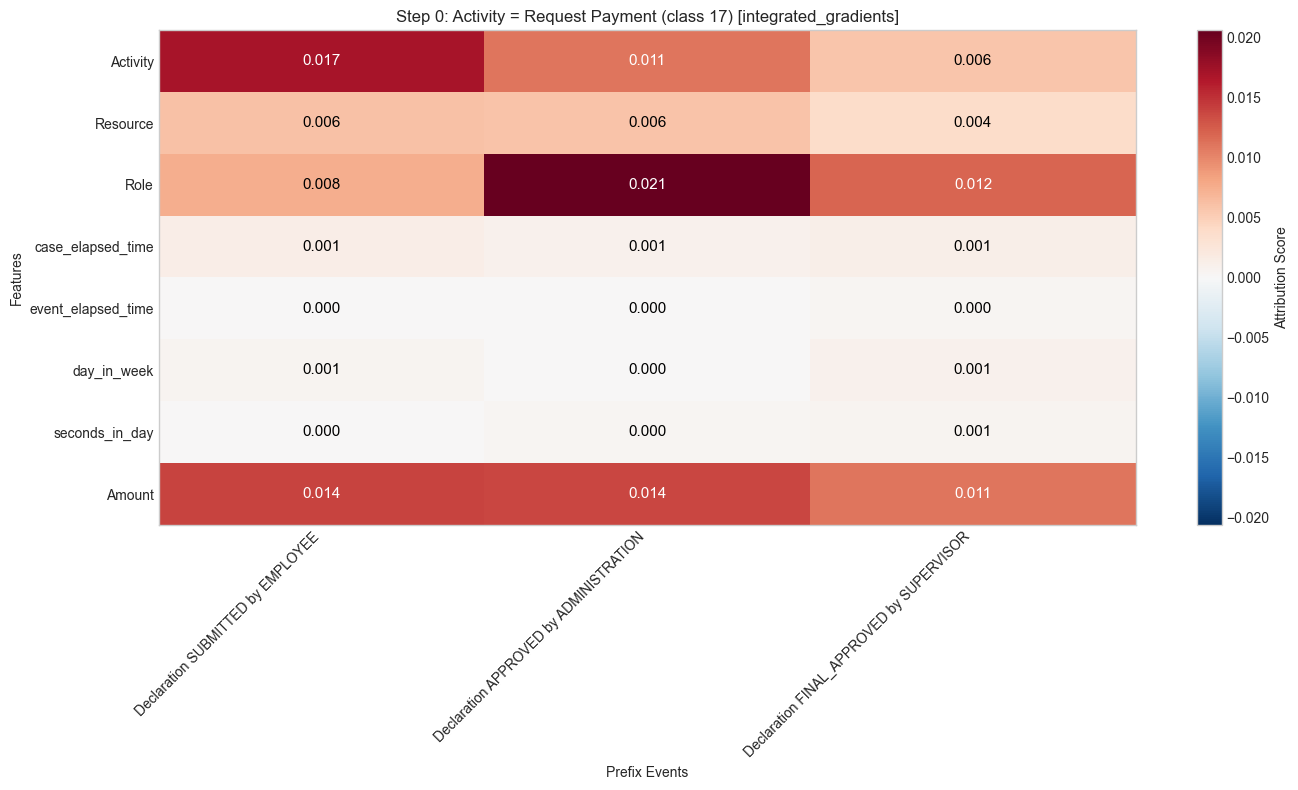

ATTRIBUTION MAP: Activity = Request Payment (class 17) [integrated_gradients]
Prefix length: 3 | Suffix scope: step
Convergence delta: 0.000156

                      Declaratio..Declaratio..Declaratio..
----------------------------------------------------------
            Activity |      0.0169      0.0110      0.0056
            Resource |      0.0061      0.0059      0.0038
                Role |      0.0075      0.0206      0.0120
   case_elapsed_time |      0.0013      0.0008      0.0013
  event_elapsed_time |      0.0000      0.0000      0.0004
         day_in_week |      0.0006      0.0000      0.0010
      seconds_in_day |      0.0001      0.0004      0.0005
              Amount |      0.0139      0.0138      0.0111
----------------------------------------------------------
               TOTAL |      0.0465      0.0526      0.0356

SUFFIX STEP 1: Activity = Payment Handled (class 16) [integrated_gradients]


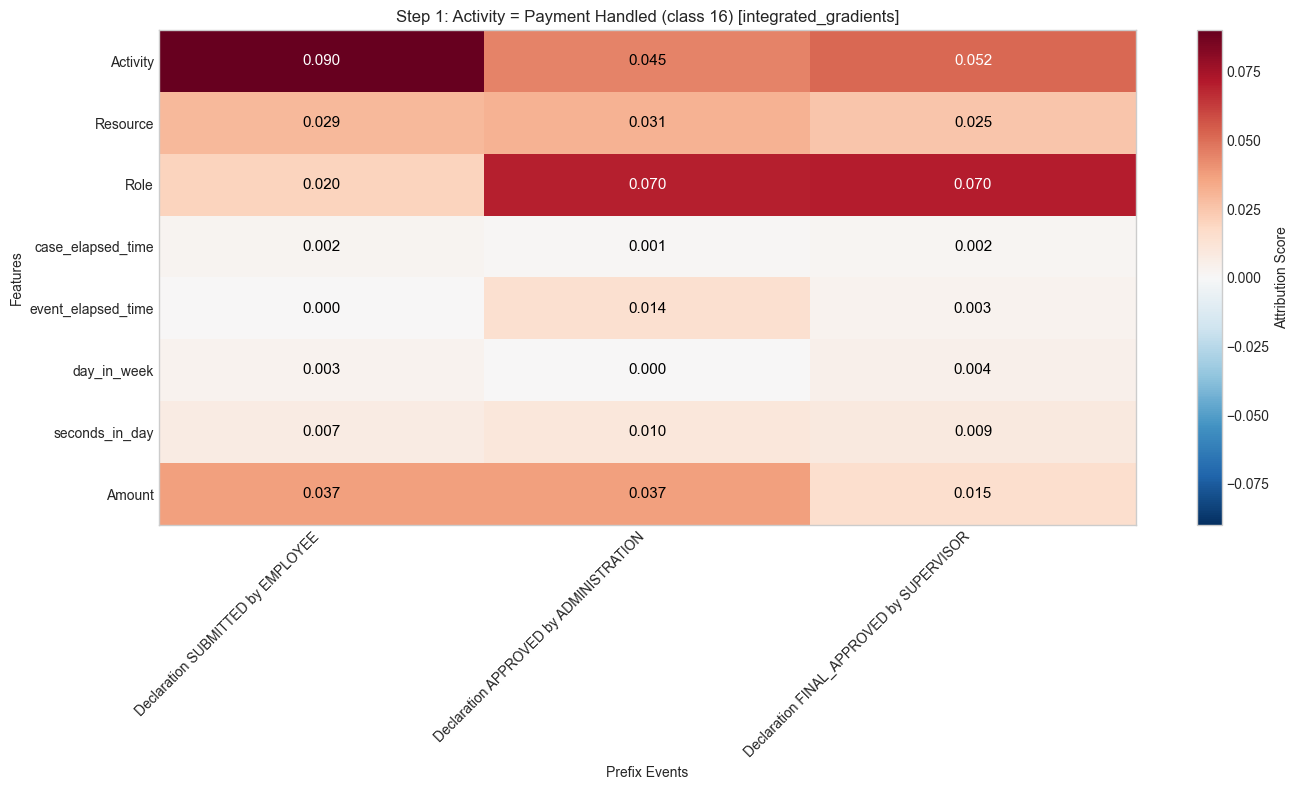

ATTRIBUTION MAP: Activity = Payment Handled (class 16) [integrated_gradients]
Prefix length: 3 | Suffix scope: step
Convergence delta: 0.000286

                      Declaratio..Declaratio..Declaratio..
----------------------------------------------------------
            Activity |      0.0900      0.0445      0.0520
            Resource |      0.0290      0.0311      0.0252
                Role |      0.0203      0.0701      0.0704
   case_elapsed_time |      0.0025      0.0011      0.0020
  event_elapsed_time |      0.0000      0.0143      0.0028
         day_in_week |      0.0029      0.0004      0.0042
      seconds_in_day |      0.0075      0.0101      0.0088
              Amount |      0.0366      0.0367      0.0152
----------------------------------------------------------
               TOTAL |      0.1887      0.2084      0.1806

SUFFIX STEP 2: EOS


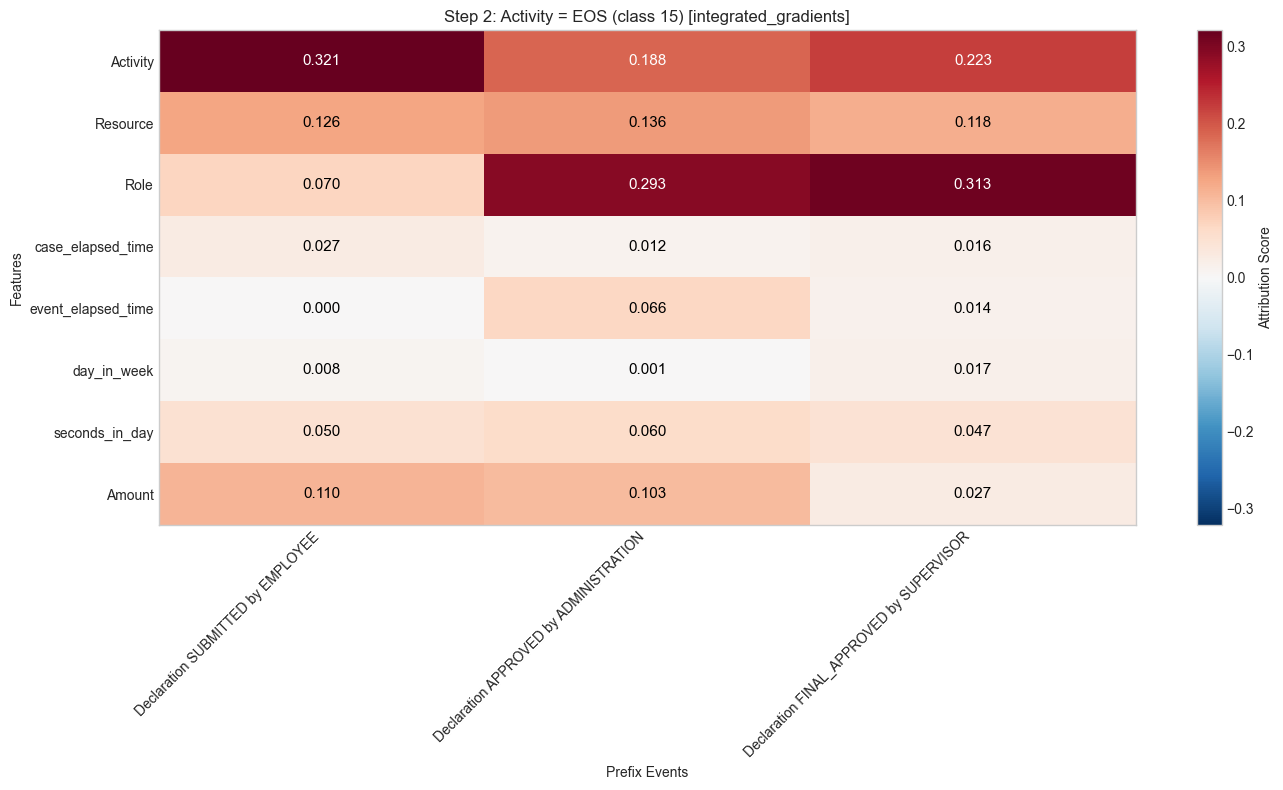

ATTRIBUTION MAP: Activity = EOS (class 15) [integrated_gradients]
Prefix length: 3 | Suffix scope: step
Convergence delta: 0.000285

                      Declaratio..Declaratio..Declaratio..
----------------------------------------------------------
            Activity |      0.3208      0.1879      0.2228
            Resource |      0.1262      0.1365      0.1176
                Role |      0.0697      0.2927      0.3128
   case_elapsed_time |      0.0267      0.0118      0.0162
  event_elapsed_time |      0.0000      0.0663      0.0137
         day_in_week |      0.0082      0.0012      0.0166
      seconds_in_day |      0.0495      0.0601      0.0467
              Amount |      0.1099      0.1026      0.0271
----------------------------------------------------------
               TOTAL |      0.7110      0.8591      0.7735


In [9]:
# Display attribution for each suffix step
for suffix_step, attr_map, pred in suffix_attributions:
    print(f"\n{'='*80}")
    print(f"SUFFIX STEP {suffix_step}: {pred}")
    print('='*80)
    
    fig = plot_attribution_heatmap(attr_map, f"Step {suffix_step}: ")
    plt.show()
    
    # Also print text version
    print(attr_map.to_string())

## 5. Interactive Suffix Step Navigator

In [10]:
# Interactive widget to navigate through suffix steps
if len(suffix_attributions) > 0:
    @interact(step=widgets.IntSlider(min=0, max=len(suffix_attributions)-1, value=0, description='Suffix Step'))
    def show_step(step):
        suffix_step, attr_map, pred = suffix_attributions[step]
        
        print(f"Suffix Step {suffix_step}: Predicting {pred}")
        print(f"Convergence delta: {attr_map.convergence_delta:.6f}" if attr_map.convergence_delta else "")
        
        fig = plot_attribution_heatmap(attr_map, f"Step {suffix_step}: ")
        plt.show()
else:
    print("No suffix attributions computed.")

interactive(children=(IntSlider(value=0, description='Suffix Step', max=2), Output()), _dom_classes=('widget-i…

## 6. Feature Importance Across Suffix Steps

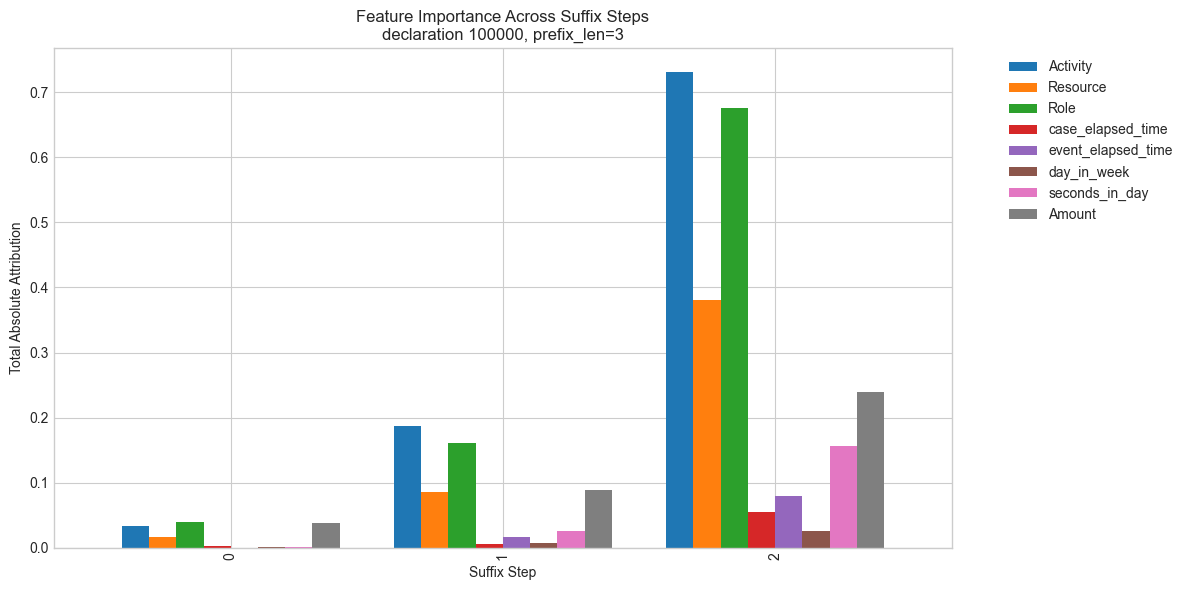


Feature importance by suffix step:


,Activity,Resource,Role,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,Amount
Suffix Step,,,,,,,,
0,0.033583,0.015877,0.040116,0.003377,0.000413,0.001587,0.001008,0.038713
1,0.186511,0.085286,0.160834,0.005666,0.017151,0.007444,0.026389,0.088445
2,0.731496,0.380325,0.675254,0.054602,0.079955,0.025981,0.156304,0.239669


In [11]:
# Aggregate feature importance across all suffix steps
if suffix_attributions:
    feature_importance_by_step = {}
    
    for suffix_step, attr_map, pred in suffix_attributions:
        feature_importance_by_step[suffix_step] = {}
        
        for feat in attr_map.feature_names:
            if feat in attr_map.attributions:
                vals = attr_map.attributions[feat]
                if hasattr(vals, 'detach'):
                    vals = vals.detach().cpu().numpy()
                feature_importance_by_step[suffix_step][feat] = np.abs(vals).sum()
    
    # Create DataFrame
    importance_df = pd.DataFrame(feature_importance_by_step).T
    importance_df.index.name = 'Suffix Step'
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 6))
    importance_df.plot(kind='bar', ax=ax, width=0.8)
    ax.set_xlabel('Suffix Step')
    ax.set_ylabel('Total Absolute Attribution')
    ax.set_title(f'Feature Importance Across Suffix Steps\n{CASE_NAME}, prefix_len={PREFIX_LENGTH}')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    
    print("\nFeature importance by suffix step:")
    display(importance_df)

## 7. Encoder vs Decoder Split

Encoder vs Decoder Attribution Split:
  Encoder: 71.0% (total: 0.5820)
  Decoder SOS: 29.0% (total: 0.2374)


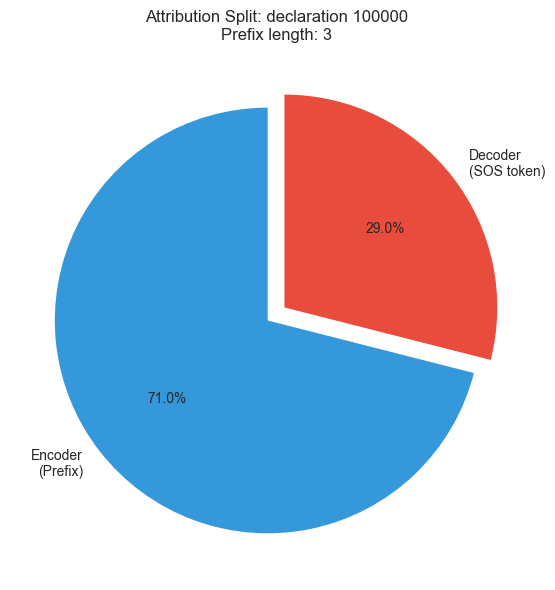

In [12]:
# Compute encoder vs decoder split for first suffix step
if suffix_attributions:
    cat_tensors = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[0]]
    num_tensors = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[1]]
    process = (cat_tensors, num_tensors)
    
    actual_len, prefix_for_split = tool.extract_prefix_from_process(process, PREFIX_LENGTH)
    
    split = tool.compute_encoder_decoder_attribution_split(
        prefix=prefix_for_split,
        target_output=TARGET,
        target_value='auto',
        suffix_step=0,
        n_steps=CONFIG.ig_steps
    )
    
    print(f"Encoder vs Decoder Attribution Split:")
    print(f"  Encoder: {split['encoder_fraction']*100:.1f}% (total: {split['encoder_total']:.4f})")
    print(f"  Decoder SOS: {split['decoder_sos_fraction']*100:.1f}% (total: {split['decoder_sos_total']:.4f})")
    
    # Visualize
    fig, ax = plt.subplots(figsize=(8, 6))
    labels = ['Encoder\n(Prefix)', 'Decoder\n(SOS token)']
    sizes = [split['encoder_fraction'], split['decoder_sos_fraction']]
    colors = ['#3498db', '#e74c3c']
    
    ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
           startangle=90, explode=(0.05, 0.05))
    ax.set_title(f'Attribution Split: {CASE_NAME}\nPrefix length: {PREFIX_LENGTH}')
    plt.tight_layout()
    plt.show()

## 8. Summary

In [14]:
print("="*80)
print(f"SUMMARY: Single Case Attribution Analysis")
print("="*80)
print(f"\nCase: {CASE_NAME}")
print(f"Prefix length: {PREFIX_LENGTH}")
print(f"Target: {TARGET}")
print(f"\nSuffix predictions:")
for step, attr_map, pred in suffix_attributions:
    print(f"  Step {step}: {pred}")

if suffix_attributions:
    print(f"\nTop features (first suffix step):")
    first_attr = suffix_attributions[0][1]
    feature_totals = {}
    for feat in first_attr.feature_names:
        if feat in first_attr.attributions:
            vals = first_attr.attributions[feat]
            if hasattr(vals, 'detach'):
                vals = vals.detach().cpu().numpy()
            feature_totals[feat] = np.abs(vals).sum()
    
    for feat, val in sorted(feature_totals.items(), key=lambda x: x[1], reverse=True)[:5]:
        print(f"  {feat}: {val:.4f}")

SUMMARY: Single Case Attribution Analysis

Case: declaration 100000
Prefix length: 3
Target: Activity

Suffix predictions:
  Step 0: Activity = Request Payment (class 17) [integrated_gradients]
  Step 1: Activity = Payment Handled (class 16) [integrated_gradients]
  Step 2: EOS

Top features (first suffix step):
  Role: 0.0401
  Amount: 0.0387
  Activity: 0.0336
  Resource: 0.0159
  case_elapsed_time: 0.0034
